# 验证TPU三维有限元模型和数值模型是否是一套

In [3]:
import comtypes.client
import comtypes.automation
import numpy as np
import os
import matplotlib.pyplot as plt
import time
import json
from pathlib import Path

# 设置matplotlib支持中文显示
import matplotlib
# 设置全局字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
matplotlib.rcParams['font.family'] = 'sans-serif'  # 使用无衬线字体

class SAP2000Model:
    def __init__(self, beam_connections, column_connections, model_path):
        self.joint_tags = []
        self.joint_coords = []

        self.beam_tags = []
        self.beam_connections = beam_connections
        self.beam_section = []

        self.column_tags = []
        self.column_connections = column_connections
        self.column_section = []

        self.joint_displacements = []
        self.joint_Accelerations = []
        self.joint_Velocities = []

        self.program_path = 'C:\\Program Files\\Computers and Structures\\SAP2000 24\\SAP2000.exe' # SAP2000程序路径
        self.model_path = model_path
        self.sap_object = None
        self.model = None

    def init_sap2000(self): # 初始化SAP2000
        helper = comtypes.client.CreateObject('SAP2000v1.Helper') # 创建SAP2000帮助对象
        helper = helper.QueryInterface(comtypes.gen.SAP2000v1.cHelper) # 获取SAP2000帮助对象
        
        self.sap_object = helper.GetObject("CSI.SAP2000.API.SapObject") # 获取当前运行的SAP2000对象
        if self.sap_object is None:
            print('未获得当前运行的SAP2000.\n正在打开SAP2000...')
            self.sap_object = helper.CreateObject(self.program_path)
        self.sap_object.ApplicationStart()      # 启动SAP2000
        self.model = self.sap_object.SapModel   # 获取SAP2000模型对象
        self.model.InitializeNewModel()         # 初始化新模型
        # self.File.OpenFile(self.model_path)   # 打开模型文件
        self.model.File.NewBlank()              # 新建空白模型
        self.model.File.Save(self.model_path)   # 保存模型
        self.model.SetPresentUnits(9)           # 设置单位为kN_mm_C
        self.sap_object.Visible = True          # 设置SAP2000界面可见

    def create_joints(self,joint_coords): # 创建节点
        for i, coord in enumerate(joint_coords):
            x, y, z = coord
            # print(f"Adding joint {i + 1} at coordinates ({x}, {y}, {z})")
            self.model.PointObj.AddCartesian(x, y, z, '', str(i + 1))   # 添加节点
            
            self.joint_tags.append(i + 1)
            self.joint_coords.append(coord)

    def define_material(self, material_name, material_type, fc, E): # 定义材料
        region = "China"
        standard = "GB"
        Grade = 'GB50010 ' + material_name
        print(f'设置材料等级为：{Grade}')
        self.model.PropMaterial.AddMaterial(material_name, material_type, region, standard, Grade)
        nu = 0.2
        A = 1.0e-5
        return material_name

    def define_section(self, section_name, material_name, b, h):
        ret = self.model.PropFrame.SetRectangle(section_name, material_name, h, b)
        if ret != 0:
            print(f"Failed to define section {section_name}")
        # 设置截面属性修正系数
        ModValues = [1, 0, 0, 1, 1, 1, 1, 1]  # 修正系数数组
        ret = self.model.PropFrame.SetModifiers(section_name, ModValues)
        if ret[-1] != 0:
            print(f"Failed to set modifiers for section {section_name}")
        return section_name

    def create_beams(self, section_name):
        for i, connection in enumerate(self.column_connections+self.beam_connections):
            start_joint, end_joint = connection
            # print(f"Adding beam from joint {start_joint} to joint {end_joint}")
            ret = self.model.FrameObj.AddByPoint(str(start_joint), str(end_joint), '', '', f'B{i + 1}')
            ret = self.model.FrameObj.SetSection(f'B{i + 1}', f'{section_name[i]}')
            # if ret != 0:
            #     print(f"Failed to set section {beam_section_name} to frame elements")

    def create_constraints(self,joint_tags_boundry_conditions):
        for i in joint_tags_boundry_conditions:
            self.model.PointObj.SetRestraint(str(i), [True, True, True, True, True, True])

    # 创建刚性隔板
    def create_rigid_diaphragm(self):
        floor_grops = {}
        for joint in self.joint_tags:
            x,y,z = self.joint_coords[joint-1]
            if z not in floor_grops:
                floor_grops[z] = []
            floor_grops[z].append(joint)
        # print(f'floor_grops:{floor_grops}')

        # 创建刚性隔板
        for floor in floor_grops:
            joints_tag = floor_grops[floor]
            # print(f'joints_tag:{joints_tag}')
            # 定义刚性隔板名称：这里以刚性隔板的节点编号为名称
            self.model.ConstraintDef.SetDiaphragm(f'floor_{floor}')
            for i in joints_tag:
                # print(f'{i}---floor_{floor}')
                self.model.PointObj.SetConstraint(str(i),f'floor_{floor}')
    
            
    def create_loads(self, joint_tags, load_values):
        # try:
        #     self.model.LoadPatterns.Delete("DEAD")
        #     self.model.LoadPatterns.Delete("Live")
        #     self.model.LoadPatterns.Delete("Wind_X")
        #     self.model.LoadPatterns.Delete("MODAL")
        # except:
        #     print("Failed to delete load patterns")

        # 定义荷载模式
        ret = self.model.LoadPatterns.Add("Live", 3, 0, True)
        if ret != 0:
            print(f"添加活载模式Live失败，错误码: {ret}")
        ret = self.model.LoadPatterns.Add("Wind_X", 6, 0, True)
        if ret != 0:
            print(f"添加风载模式Wind_X失败，错误码: {ret}")
        ret = self.model.LoadPatterns.Add("Wind_Y", 6, 0, True)
        if ret != 0:
            print(f"添加风载模式Wind_Y失败，错误码: {ret}")
        
        # 定义质量源
        LoadPat = ["DEAD", "Live"]  # Define load patterns
        SF = [1.0, 0.5]  # Define scale factors
        ret = self.model.SourceMass.SetMassSource("MyMassSource", True, True, True, True, 2, LoadPat, SF)
        if ret[-1] != 0:
            print(f"设置自重工况DEAD失败，错误码: {ret}")
        ret = self.model.SourceMass.SetDefault("MyMassSource")

        # number_points = self.model.PointObj.Count() # 获取节点总数
        for joint_tag, load_value in zip(joint_tags, load_values):
            ret = self.model.PointObj.SetLoadForce(str(joint_tag), "Wind_X", load_value, False, "Global")
        


    def create_analysis_combos(self):
        try:
            self.model.RespCombo.Delete("Combo1")
        except:
            print("Failed to delete response Combo1")

        ret = self.model.RespCombo.Add("Combo2", 1)
        if ret != 0:
            print(f"添加分析组合失败，错误码: {ret}")
        ret = self.model.RespCombo.SetCaseList("Combo2", 0, "DEAD", 1.3)
        ret = self.model.RespCombo.SetCaseList("Combo2", 0, "Live", 1.3)
        ret = self.model.RespCombo.SetCaseList("Combo2", 0, "Wind_X", 1.5)

    def create_analysis_parameters(self):
        ret = self.model.Analyze.SetRunCaseFlag("DEAD", True)
        if ret != 0:
            print("Failed to set run case flag for load case DEAD")
        ret = self.model.Analyze.SetRunCaseFlag("Live", False)
        if ret != 0:
            print("Failed to set run case flag for load case Live")
        ret = self.model.Analyze.SetRunCaseFlag("Wind_X", True)
        if ret != 0:
            print("Failed to set run case flag for load case Wind_X")
        ret = self.model.Analyze.SetRunCaseFlag("MODAL", False)
        if ret != 0:
            print("Failed to set run case flag for load case MODAL")

    def create_analysis_model(self, analysis_type=1):
        """创建分析模型
        
        Args:
            analysis_type: 分析类型，1为静力分析，2为动力分析，默认为1
        """
        # 根据分析类型创建不同的分析模型
        if analysis_type == 1:  # 静力分析
            print("直接创建静力分析模型")
        elif analysis_type == 2:  # 动力分析
            print("创建动力分析模型")
            # 设置时程分析参数
            ret = self.model.LoadCases.ModalEigen.SetCase("MODAL")
            ret = self.model.LoadCases.ModalEigen.SetNumberModes(10)
            ret = self.model.LoadCases.ModalEigen.SetEigenShift(0.0)
            ret = self.model.LoadCases.ModalEigen.SetMaxCycles(20)
            ret = self.model.LoadCases.ModalEigen.SetToleranceForDiagonalTerms(1.0e-9)
            ret = self.model.LoadCases.ModalEigen.SetTrialsPerVector(20)
            
        # 创建分析模型
        self.model.Analyze.CreateAnalysisModel()

    def run_analysis(self):
        ret = self.model.Analyze.RunAnalysis()
        if ret != 0:
            print(f"分析运行失败，错误代码：{ret}")
        else:
            print("SAP2000分析运行成功")

    def get_results(self, joint_tags):
        
        Obj, Elm, ACase, StepType, StepNum = [], [], [], [], []
        U1, U2, U3, R1, R2, R3 = [], [], [], [], [], []
        ObjectElm, NumberResults = 0, 0

        try:
            # 选择输出结果的工况
            ret = self.model.Results.Setup.DeselectAllCasesAndCombosForOutput()
            if ret != 0:
                print(f"取消选择所有工况失败，错误代码：{ret}")
                return []
            
            ret = self.model.Results.Setup.SetCaseSelectedForOutput("Wind_X")  # 改为您实际需要的工况
            if ret != 0:
                print(f"选择输出工况失败，错误代码：{ret}")
                return []
            
            # 获取关节位移，使用ALL获取所有节点的结果
            [NumberResults, Obj, Elm, ACase, StepType, StepNum, U1, U2, U3, R1, R2, R3, ret] = \
            self.model.Results.JointDispl(str(joint_tags), ObjectElm, NumberResults, Obj, Elm, ACase, StepType, StepNum, U1, U2, U3, R1, R2, R3)
            
            if ret != 0:
                print(f"获取节点位移结果失败，错误代码：{ret}")
                return []
            
            result = [U1[0], U2[0], U3[0], R1[0], R2[0], R3[0]]
            return result
            
        except Exception as e:
            print(f"获取结果时出错: {e}")
            import traceback # 引入traceback模块,打印错误信息,可以追踪错误
            traceback.print_exc() # 打印异常信息
            return []

    def visualize_results(self):
        plt.plot()
        plt.title('Beam Shear Force')
        plt.xlabel('Element Index')
        plt.ylabel('Shear Force (kN)')
        plt.show()

    def save_model(self):
        # 检查self.model_path的倒数第二个文件夹是否存在
        # 如果不存在，则创建该文件夹
        if not os.path.exists(os.path.dirname(self.model_path)):
            os.makedirs(os.path.dirname(self.model_path))
        # 检查self.model_path的最后一个文件夹是否存在
        # if not os.path.exists(self.model_path):
        #     os.makedirs(self.model_path)
        self.model.File.Save(self.model_path)
        

    def close_sap2000(self):
        self.sap_object.ApplicationExit(True)
        self.sap_object = None
        self.model = None

    def define_time_history_load(self, gm_file, scale_factor=1.0):
        """定义时程荷载（地震波）
        
        Args:
            gm_file: 地震波文件路径
            scale_factor: 地震波缩放系数，默认为1.0
        """
        # 读取地震波数据
        try:
            gm_data = np.loadtxt(gm_file)
            time_points = gm_data[:, 0]
            accel_values = gm_data[:, 1] * scale_factor
            
            # 创建函数型时程
            ret = self.model.Func.FuncTH.Delete("ELCENTRO")
            ret = self.model.Func.FuncTH.SetFromFile("ELCENTRO", gm_file, 1, 0, 1, 2, 
                                                    True, 1.0, 0.0, 0.0, 0)
            
            # 创建时程分析案例
            ret = self.model.LoadCases.Delete("TimeHistory")
            ret = self.model.LoadCases.StaticLinear.SetCase("TimeHistory")
            
            print(f"成功读取地震波文件，共{len(time_points)}个时间点")
            return True
        except Exception as e:
            print(f"读取地震波文件或定义时程分析失败: {e}")
            import traceback
            traceback.print_exc()
            return False
            
    def get_modal_results(self, num_modes=3):
        """获取模态分析结果
        
        Args:
            num_modes: 要获取的模态数量
            
        Returns:
            modal_periods: 模态周期列表
            modal_freqs: 模态频率列表
        """
        try:
            # 确保MODAL工况被选择
            ret = self.model.Results.Setup.DeselectAllCasesAndCombosForOutput()
            ret = self.model.Results.Setup.SetCaseSelectedForOutput("MODAL")
            
            modal_periods = []
            modal_freqs = []
            
            for mode in range(1, num_modes + 1):
                [period, frequency, circular_freq, eigen_value, ret] = self.model.Results.ModalPeriod(mode)
                if ret == 0:
                    modal_periods.append(period)
                    modal_freqs.append(frequency)
                else:
                    print(f"获取模态 {mode} 结果失败，错误码: {ret}")
            
            return modal_periods, modal_freqs
        except Exception as e:
            print(f"获取模态分析结果失败: {e}")
            import traceback
            traceback.print_exc()
            return [], []
    
    def export_results_to_file(self, output_dir):
        """将分析结果导出到文件
        
        Args:
            output_dir: 输出目录
        """
        try:
            # 创建输出目录
            output_path = Path(output_dir)
            output_path.mkdir(parents=True, exist_ok=True)
            
            # 导出位移结果
            disp_file = output_path / "nodal_displacements.txt"
            ret = self.model.DatabaseTables.SetLoadCasesSelectedForDisplay(["Wind_X"])
            ret = self.model.DatabaseTables.SetTableKeyNameList("Joint Displacements", ["Joint"])
            ret = self.model.DatabaseTables.ExportToTextFile(str(disp_file), "Joint Displacements")
            
            # 导出反力结果
            force_file = output_path / "joint_reactions.txt"
            ret = self.model.DatabaseTables.ExportToTextFile(str(force_file), "Joint Reactions")
            
            print(f"分析结果已导出到 {output_dir}")
            return True
        except Exception as e:
            print(f"导出结果失败: {e}")
            import traceback
            traceback.print_exc()
            return False
            
    def plot_displacement_results(self, output_dir=None):
        """绘制位移结果
        
        Args:
            output_dir: 输出目录，如果为None则不保存图片
        """
        try:
            # 获取所有节点的位移
            all_displacements = []
            for tag in self.joint_tags:
                disp = self.get_results(tag)
                if disp:
                    all_displacements.append(disp)
            
            if not all_displacements:
                print("没有可用的位移数据可绘制")
                return False
                
            # 转换为NumPy数组便于处理
            all_displacements = np.array(all_displacements)
            
            # 创建绘图
            plt.figure(figsize=(12, 8))
            
            # 绘制X方向位移
            plt.subplot(2, 2, 1)
            heights = [self.joint_coords[i-1][2] for i in self.joint_tags]
            plt.scatter(all_displacements[:, 0], heights, c='b', alpha=0.7)
            plt.title('X方向位移')
            plt.xlabel('位移 (mm)')
            plt.ylabel('高度 (mm)')
            plt.grid(True)
            
            # 绘制Y方向位移
            plt.subplot(2, 2, 2)
            plt.scatter(all_displacements[:, 1], heights, c='r', alpha=0.7)
            plt.title('Y方向位移')
            plt.xlabel('位移 (mm)')
            plt.ylabel('高度 (mm)')
            plt.grid(True)
            
            # 绘制Z方向位移
            plt.subplot(2, 2, 3)
            plt.scatter(all_displacements[:, 2], heights, c='g', alpha=0.7)
            plt.title('Z方向位移')
            plt.xlabel('位移 (mm)')
            plt.ylabel('高度 (mm)')
            plt.grid(True)
            
            # 绘制总位移
            plt.subplot(2, 2, 4)
            total_disp = np.sqrt(all_displacements[:, 0]**2 + all_displacements[:, 1]**2 + all_displacements[:, 2]**2)
            plt.scatter(total_disp, heights, c='purple', alpha=0.7)
            plt.title('总位移')
            plt.xlabel('位移 (mm)')
            plt.ylabel('高度 (mm)')
            plt.grid(True)
            
            plt.tight_layout()
            
            # 保存图片
            if output_dir:
                output_path = Path(output_dir)
                output_path.mkdir(parents=True, exist_ok=True)
                plt.savefig(str(output_path / "displacement_results.png"), dpi=300)
                print(f"位移结果图已保存至 {output_path / 'displacement_results.png'}")
            
            plt.show()
            return True
        except Exception as e:
            print(f"绘制位移结果失败: {e}")
            import traceback
            traceback.print_exc()
            return False


In [4]:
"""测试 SAP2000Model 类功能"""
print("="*50)
print("SAP2000Model 测试程序")
print("="*50)

# 设置测试参数
analysis_type = 1  # 1为静力分析，2为动力分析
print(f"测试分析类型: {analysis_type} ({'静力分析' if analysis_type == 1 else '动力分析'})")

# 创建输出目录
output_dir = './data/output/sap2000_test'
Path(output_dir).mkdir(parents=True, exist_ok=True)

# 设置模型基本信息
joint_coords = np.array([
    [0, 0, 0], [6000, 0, 0], [12000, 0, 0],
    [0, 6000, 0], [6000, 6000, 0], [12000, 6000, 0],
    [0, 0, 4000], [6000, 0, 4000], [12000, 0, 4000],
    [0, 6000, 4000], [6000, 6000, 4000], [12000, 6000, 4000],
    [0, 0, 8000], [6000, 0, 8000], [12000, 0, 8000],
    [0, 6000, 8000], [6000, 6000, 8000], [12000, 6000, 8000],
])

# 定义梁柱连接
column_connections = [
    [1, 7], [2, 8], [3, 9], [4, 10], [5, 11], [6, 12],  # 一层柱
    [7, 13], [8, 14], [9, 15], [10, 16], [11, 17], [12, 18],  # 二层柱
]

# 定义梁连接（X方向和Y方向）
beam_connections_x = [
    [7, 8], [8, 9], [10, 11], [11, 12],  # 二层X方向
    [13, 14], [14, 15], [16, 17], [17, 18],  # 三层X方向
]

beam_connections_y = [
    [7, 10], [8, 11], [9, 12],  # 二层Y方向
    [13, 16], [14, 17], [15, 18],  # 三层Y方向
]

beam_connections = beam_connections_x + beam_connections_y

# 创建SAP2000模型
timestamp = time.strftime("%Y%m%d-%H%M%S")
model_path = f"D:\\MyFiles\\PhD\\optimization\\Model\\creatmodel\\Models_FEM\\Model_SAP2000_test_{timestamp}\\Model_SAP2000_test_{timestamp}.sdb"


SAP2000Model 测试程序
测试分析类型: 1 (静力分析)



1. 初始化SAP2000模型...

2. 创建节点...
  创建了 18 个节点

3. 定义材料和截面...
设置材料等级为：GB50010 C60
设置材料等级为：GB50010 C80
  创建了 26 个截面

4. 创建梁柱构件...

5. 创建边界约束...

6. 创建刚性隔板...

7. 应用荷载...

8. 创建分析参数...

9. 创建分析模型...
直接创建静力分析模型

10. 保存模型...

11. 运行分析...
SAP2000分析运行成功

12. 获取结果...
  节点 13 位移结果: [0.003066979868207168, 2.270101725704336e-18, 1.73089408611107e-05, -2.238557532721631e-22, 3.1512229070154517e-07, -3.7797226879452977e-22]
  节点 14 位移结果: [0.003066979868207168, 2.2681129371578396e-21, 1.6564117855444258e-21, -5.148248224561481e-25, 1.7773327870412454e-07, -3.7797226879452977e-22]
  节点 15 位移结果: [0.003066979868207168, -2.2655654998300213e-18, -1.7308940861110698e-05, 2.2292517508304096e-22, 3.1512229070154495e-07, -3.7797226879452977e-22]
  节点 16 位移结果: [0.00306697986820717, 2.270101725704336e-18, 1.730894086111069e-05, -2.2433049846468447e-22, 3.1512229070154517e-07, -3.7797226879452977e-22]
  节点 17 位移结果: [0.00306697986820717, 2.2681129371578396e-21, -1.862378468426248e-21, -5.211723111214789e-25, 1.77

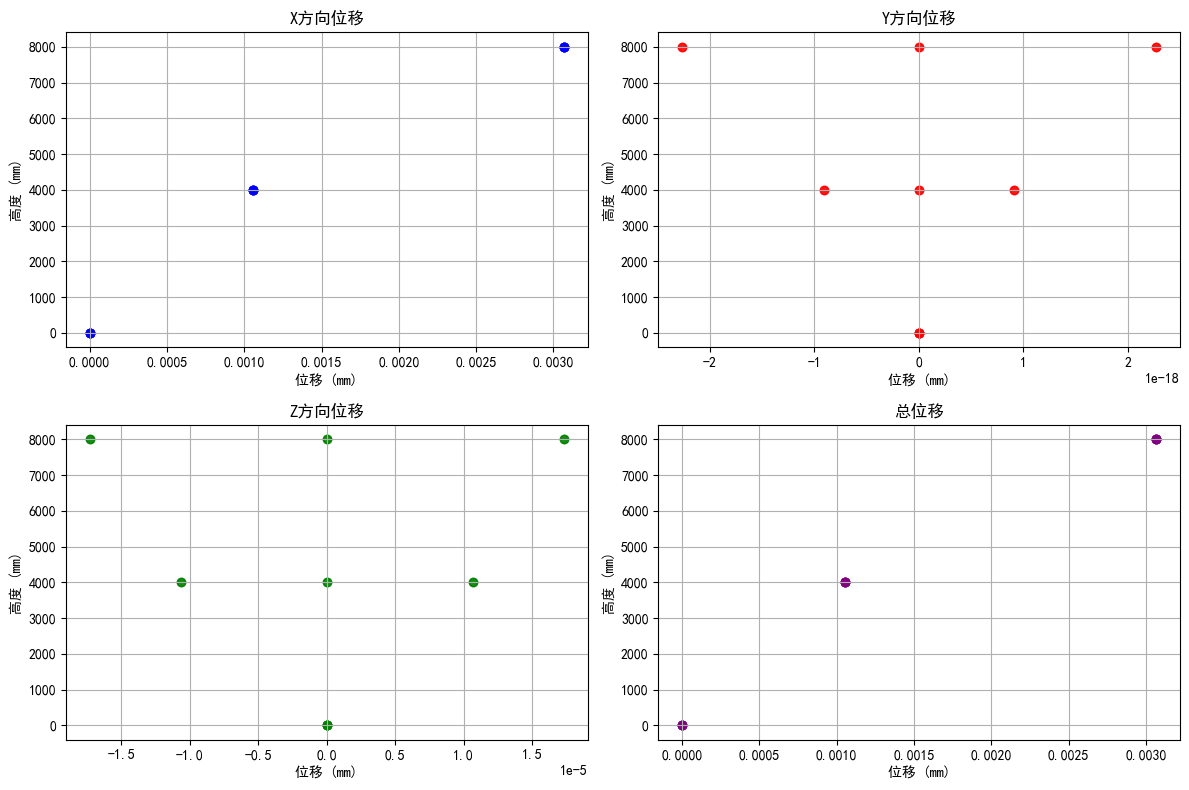

导出结果失败: SetTableKeyNameList

13. 测试完成
  模型文件已保存至: D:\MyFiles\PhD\optimization\Model\creatmodel\Models_FEM\Model_SAP2000_test_20250707-094040\Model_SAP2000_test_20250707-094040.sdb
  结果已保存至: ./data/output/sap2000_test


Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\pytorch_cuda\Lib\site-packages\comtypes\_post_coinit\_cominterface_meta_patcher.py", line 17, in __getattr__
    fixed_name = self.__map_case__[name.lower()]
                 ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
KeyError: 'settablekeynamelist'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\HIT\AppData\Local\Temp\ipykernel_21028\2470586742.py", line 345, in export_results_to_file
    ret = self.model.DatabaseTables.SetTableKeyNameList("Joint Displacements", ["Joint"])
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\envs\pytorch_cuda\Lib\site-packages\comtypes\_post_coinit\_cominterface_meta_patcher.py", line 19, in __getattr__
    raise AttributeError(name)  # Should we use exception-chaining?
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: SetTableKeyNameList


In [6]:
print("\n1. 初始化SAP2000模型...")
sap_model = SAP2000Model(beam_connections, column_connections, model_path)
sap_model.init_sap2000()

print("\n2. 创建节点...")
sap_model.create_joints(joint_coords)
print(f"  创建了 {len(sap_model.joint_tags)} 个节点")

print("\n3. 定义材料和截面...")
beam_material_name = sap_model.define_material("C60", 2, 40, 3.6e4)
column_material_name = sap_model.define_material("C80", 2, 50, 3.8e4)

# 创建不同尺寸的截面
section_names = []

# 柱截面 - 不同层的柱截面尺寸不同
for i in range(len(column_connections)):
    if i < 6:  # 一层柱
        section_name = sap_model.define_section(f"Column600x600_{i+1}", column_material_name, 600, 600)
    else:  # 二层柱
        section_name = sap_model.define_section(f"Column500x500_{i+1}", column_material_name, 500, 500)
    section_names.append(section_name)

# 梁截面 - X方向和Y方向可以使用不同的截面
for i in range(len(beam_connections)):
    if i < len(beam_connections_x):  # X方向梁
        section_name = sap_model.define_section(f"BeamX300x600_{i+1}", beam_material_name, 300, 600)
    else:  # Y方向梁
        section_name = sap_model.define_section(f"BeamY300x500_{i+1}", beam_material_name, 300, 500)
    section_names.append(section_name)

print(f"  创建了 {len(section_names)} 个截面")

print("\n4. 创建梁柱构件...")
sap_model.create_beams(section_names)

print("\n5. 创建边界约束...")
joint_tags_boundry_conditions = list(range(1, 7))  # 底部6个节点固定
sap_model.create_constraints(joint_tags_boundry_conditions)

print("\n6. 创建刚性隔板...")
sap_model.create_rigid_diaphragm()

print("\n7. 应用荷载...")
if analysis_type == 1:  # 静力分析
    # 创建风荷载 - 只施加到顶层节点
    load_values = [[0, 0, 0, 0, 0, 0] for _ in range(len(sap_model.joint_tags))]
    for i in range(13, 19):  # 顶层节点
        load_values[i-1] = [30, 0, 0, 0, 0, 0]  # X方向30kN风荷载
    
    sap_model.create_loads(sap_model.joint_tags, load_values)
    
elif analysis_type == 2:  # 动力分析
    # 读取地震波
    gm_file = r"D:\MyFiles\git\Highrise-Structure-Optimization\tests\ELCENTRO.txt"
    if Path(gm_file).exists():
        print(f"  使用地震波文件: {gm_file}")
        sap_model.define_time_history_load(gm_file, scale_factor=1.0)
    else:
        print(f"  地震波文件不存在: {gm_file}")
        # 创建简单荷载代替
        load_values = [[0, 0, 0, 0, 0, 0] for _ in range(len(sap_model.joint_tags))]
        sap_model.create_loads(sap_model.joint_tags, load_values)

print("\n8. 创建分析参数...")
sap_model.create_analysis_combos()
sap_model.create_analysis_parameters()

print("\n9. 创建分析模型...")
sap_model.create_analysis_model(analysis_type)

print("\n10. 保存模型...")
sap_model.save_model()

print("\n11. 运行分析...")
sap_model.run_analysis()

print("\n12. 获取结果...")
if analysis_type == 1:  # 静力分析
    # 获取顶层节点位移结果
    for i in range(13, 19):
        result = sap_model.get_results(joint_tags=i)
        print(f"  节点 {i} 位移结果: {result}")
        
    # 可视化位移结果
    sap_model.plot_displacement_results(output_dir)
    
    # 导出结果到文件
    sap_model.export_results_to_file(output_dir)
    
elif analysis_type == 2:  # 动力分析
    # 获取模态分析结果
    modal_periods, modal_freqs = sap_model.get_modal_results(num_modes=6)
    print("\n  模态分析结果:")
    for i, (period, freq) in enumerate(zip(modal_periods, modal_freqs)):
        print(f"  模态 {i+1}: 周期 = {period:.4f} 秒, 频率 = {freq:.4f} Hz")

print("\n13. 测试完成")
print(f"  模型文件已保存至: {model_path}")
print(f"  结果已保存至: {output_dir}")

# # 询问用户是否关闭SAP2000
# close_sap = input("\n是否关闭SAP2000? (y/n): ")
# if close_sap.lower() == 'y':
#     sap_model.close_sap2000()
#     print("SAP2000已关闭")
# else:
#     print("SAP2000保持打开状态")
        


